# 3C – Bangla News Text Clustering (Prothom Alo)
### K-Means Clustering | Manual TF-IDF | 3-D t-SNE | Internal & External Validation

**Dataset:** [banglanlp/bnlp-resources – news_categorization](https://github.com/banglanlp/bnlp-resources/tree/main/news_categorization)  
**Goal:** Cluster 1,200 Prothom Alo news articles (200 × 6 categories) into 6 groups  
**Pipeline:** Tokenise → Stem → Normalise → Stop-word removal → Zipf filter → Manual TF-IDF → K-Means (k=6) → Evaluate

| Step | Method |
|------|--------|
| Feature extraction | Manual TF / Norm-TF / IDF / TF-IDF (no sklearn vectoriser) |
| Clustering | K-Means (k-means++, k=6) |
| Visualisation | 3-D t-SNE projection |
| Internal validation | Davies–Bouldin Index, Dunn Index |
| External validation | Purity, Rand Index, Adjusted Rand Index |


## Cell 1 — Imports & Environment Setup

In [1]:
# ── Install required packages ─────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import bnlp
except ImportError:
    print("Installing bnlp-toolkit...")
    install("bnlp-toolkit")

for pkg, imp in [("sklearn","scikit-learn"), ("matplotlib","matplotlib"),
                 ("numpy","numpy"), ("scipy","scipy"), ("requests","requests")]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {imp}...")
        install(imp)

# ── Standard library ───────────────────────────────────────────────────────
import os, re, io, time, warnings, random
from collections import Counter

# ── Data handling ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import requests

# ── Bangla NLP stopwords ───────────────────────────────────────────────────
try:
    from bnlp.corpus._stopwords import bengali_stopwords as bnlp_stopwords
except ImportError:
    # Fallback: minimal Bangla stop-word list if bnlp import path differs
    bnlp_stopwords = [
        'ও', 'এবং', 'হয়', 'ছিল', 'করা', 'হবে',
        'হল', 'যে', 'যা', 'বলা', 'না', 'তা', 'এ',
        'আ', 'আমি', 'আমাদের', 'তার', 'সে',
        'তারা', 'বলে', 'থেকে', 'বা', 'থাকা',
        'হয়', 'হায়', 'হয়ে', 'হয়েছিল',
        'হলে', 'সাথে', 'কি', 'যখন', 'হেতু',
        'যদি', 'আর', 'ওই', 'তবে', 'তে', 'কে',
    ]

# ── ML / Visualisation ─────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score, rand_score

import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3-D projection

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("All imports successful ✓")
print(f"  bnlp stop-words loaded: {len(bnlp_stopwords)} words")


Installing bnlp-toolkit...
punkt not found. downloading...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All imports successful ✓
  bnlp stop-words loaded: 398 words


## Cell 2 — Download the Dataset

The dataset is hosted as TSV files in the bnlp-resources GitHub repo.  
**6 categories used:** `kolkata`, `state`, `national`, `sports`, `entertainment`, `international`  
**200 articles per category = 1,200 total** (sampled with `random_state=42` for reproducibility).

A local cache `news_data.csv` is written after the first download to avoid re-fetching.


In [2]:
CACHE_FILE = 'news_data.csv'
CATEGORIES_6 = ['kolkata', 'state', 'national', 'sports', 'entertainment', 'international']
N_PER_CATEGORY = 200
BASE_URL = 'https://raw.githubusercontent.com/banglanlp/bnlp-resources/main/news_categorization'

if os.path.exists(CACHE_FILE):
    # Force utf-8 + dtype=str so Bangla characters are never mangled
    df = pd.read_csv(CACHE_FILE, encoding='utf-8', dtype=str).fillna('')
    # Ensure plain Python str (not pandas StringDtype)
    df['text']     = df['text'].astype(object).apply(str)
    df['category'] = df['category'].astype(object).apply(str)
    print(f'Loaded from cache: {len(df)} rows')
else:
    records = []
    for split in ['train', 'dev', 'test']:
        r = requests.get(f'{BASE_URL}/{split}.tsv', timeout=30)
        if r.status_code == 200:
            # Use r.content + explicit utf-8 + dtype=str to preserve Bangla
            tmp = pd.read_csv(
                io.BytesIO(r.content), sep='\t',
                on_bad_lines='skip', encoding='utf-8', dtype=str
            ).fillna('')
            records.append(tmp)
            print(f'  {split}: {len(tmp)} rows')
    all_df = pd.concat(records, ignore_index=True)
    all_df = all_df[all_df['class_label'].isin(CATEGORIES_6)][['text','class_label']].copy()
    all_df.columns = ['text', 'category']
    # Guarantee plain Python str objects throughout
    all_df['text']     = all_df['text'].astype(object).apply(str)
    all_df['category'] = all_df['category'].astype(object).apply(str)
    all_df = all_df[all_df['text'].str.len() > 10].reset_index(drop=True)

    sampled = []
    for cat in CATEGORIES_6:
        sub = all_df[all_df['category'] == cat]
        n = min(N_PER_CATEGORY, len(sub))
        sampled.append(sub.sample(n, random_state=42))
        print(f'  {cat}: {n} articles sampled')
    df = pd.concat(sampled, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    df.to_csv(CACHE_FILE, index=False, encoding='utf-8')
    print(f'Saved {len(df)} articles -> {CACHE_FILE}')

print(f'\nShape: {df.shape}  |  text dtype: {df["text"].dtype}')
print('\nCategory distribution:')
print(df['category'].value_counts().to_string())

# ── Sanity check: confirm Bangla characters are present ──────────────────
sample_text = df['text'].iloc[0]
bangla_chars = sum(1 for c in sample_text if '\u0980' <= c <= '\u09FF')
print(f'\nSanity check — Bangla chars in doc[0]: {bangla_chars}')
assert bangla_chars > 0, "No Bangla chars found! Encoding problem in text column."
print('Text encoding OK \u2713')


  train: 11108 rows
  dev: 1407 rows
  test: 1406 rows
  kolkata: 200 articles sampled
  state: 200 articles sampled
  national: 200 articles sampled
  sports: 200 articles sampled
  entertainment: 200 articles sampled
  international: 200 articles sampled
Saved 1200 articles -> news_data.csv

Shape: (1200, 2)  |  text dtype: object

Category distribution:
category
international    200
entertainment    200
kolkata          200
national         200
state            200
sports           200

Sanity check — Bangla chars in doc[0]: 1487
Text encoding OK ✓


## Cell 3 — Tokenisation

Bangla text occupies Unicode range **U+0980–U+09FF**. We use a regex that:  
1. Strips all non-Bangla characters (ASCII, digits, punctuation)  
2. Splits on whitespace  
3. Discards tokens shorter than 2 characters

This avoids depending on a pre-trained sentence boundary model while being fully reproducible.


In [3]:
def bangla_tokenize(text):
    """
    Tokenise Bangla text.

    Keeps only characters in the Bangla Unicode block (U+0980-U+09FF).
    Input is coerced to a plain Python str; pd.NA / None / floats all handled.
    Returns a list of tokens with length >= 2.
    """
    # Robust coercion: handle pd.NA, None, float NaN, StringDtype scalars
    if text is None or (isinstance(text, float) and text != text):
        return []
    text = str(text)
    if text in ('<NA>', 'nan', 'None', ''):
        return []
    # Keep only Bangla Unicode block + whitespace
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)
    return [t.strip() for t in text.split() if len(t.strip()) >= 2]

# ── Debug: show what the text actually looks like ────────────────────────
sample_text = df['text'].iloc[0]
print('Text type       :', type(sample_text))
print('First 80 chars  :', sample_text[:80])
print('Hex of chars 0-2:', [hex(ord(c)) for c in sample_text[:3]])
toks = bangla_tokenize(sample_text)
print('First 12 tokens :', toks[:12])
print('Token count     :', len(toks))
assert len(toks) > 0, f"Tokenizer returned empty list for: {repr(sample_text[:80])}"
print('Tokenizer OK \u2713')


Text type       : <class 'str'>
First 80 chars  : ২৪ বছরের এক মার্কিন যুবতী বিয়ের তিন মাসের মাথায় এমন এক বাস্তবের সম্মুখীন হলেন, য
Hex of chars 0-2: ['0x9e8', '0x9ea', '0x20']
First 12 tokens : ['২৪', 'বছরের', 'এক', 'মার্কিন', 'যুবতী', 'বিয়ের', 'তিন', 'মাসের', 'মাথায়', 'এমন', 'এক', 'বাস্তবের']
Token count     : 297
Tokenizer OK ✓


## Cell 4 — Stemming

Bangla is a highly inflected language with rich suffixal morphology.  
We implement a **light rule-based stemmer** (Dasgupta & Ng 2007 style) that  
iteratively strips the most common suffixes provided the resulting stem is ≥ 2 characters long.

Suffixes are ordered **longest-first** so greedy matching works correctly.


In [4]:
# Bangla common suffixes -- longest first for greedy matching
BANGLA_SUFFIXES = [
    'গুলো', 'গুলি', 'দের', 'তার', 'তে', 'কে', 'রা', 'টি',
    'টা', 'এর', 'য়', 'ায়', 'আন', 'ইত', 'তি',
]

def bangla_stem(token):
    """
    Light suffix-stripping stemmer for Bangla.
    Removes known inflectional suffixes if the remaining stem is >= 2 chars.
    """
    for suffix in BANGLA_SUFFIXES:
        if token.endswith(suffix) and len(token) - len(suffix) >= 2:
            return token[:-len(suffix)]
    return token

# Demonstration
examples = ['ছেলেদের', 'খেলাগুলো', 'বাংলাদেশের', 'মাঠগুলি', 'সরকারতি']
print('Stemming examples:')
for w in examples:
    print(f'  {w:20s} -> {bangla_stem(w)}')


Stemming examples:
  ছেলেদের              -> ছেলে
  খেলাগুলো             -> খেলা
  বাংলাদেশের           -> বাংলাদেশের
  মাঠগুলি              -> মাঠ
  সরকারতি              -> সরকার


## Cell 5 — Normalisation, Stop-Word Removal & Full Preprocessing Pipeline

**Normalisation** removes invisible Unicode characters (zero-width joiners/non-joiners U+200B–U+200F, soft hyphen U+00AD) that can create false vocabulary splits.

**Stop-words** are removed using the `bnlp-toolkit` built-in Bangla stop-word list (398 words).

The full pipeline is: *tokenise → stem → normalise → filter stop-words*.


In [5]:
def normalize_bangla(token):
    """Remove invisible Unicode control characters from a Bangla token."""
    return re.sub(r'[\u200b-\u200f\u00ad]', '', token).strip()

# Build stop-word set from bnlp-toolkit
stop_set = set(bnlp_stopwords)
print(f'Stop-word list size : {len(stop_set)}')
print('Sample stop words   :', list(stop_set)[:6])

def preprocess(text):
    """Full pipeline: tokenise -> stem -> normalise -> remove stop-words."""
    tokens  = bangla_tokenize(text)
    stemmed = [bangla_stem(t) for t in tokens]
    normed  = [normalize_bangla(t) for t in stemmed]
    return [t for t in normed if t and t not in stop_set]

# Apply to all 1,200 documents
print('\nPreprocessing all documents...')
df['tokens'] = df['text'].apply(preprocess)

lengths = df['tokens'].apply(len)
print(f'  Avg tokens/doc : {lengths.mean():.1f}')
print(f'  Min tokens/doc : {lengths.min()}')
print(f'  Max tokens/doc : {lengths.max()}')
print('  Sample (doc 0) :', df['tokens'].iloc[0][:10])

# Per-category check
print('\nTokens per category (mean):')
for cat in CATEGORIES_6:
    mask = df['category'] == cat
    mean_len = df.loc[mask, 'tokens'].apply(len).mean()
    print(f'  {cat:20s}: {mean_len:.1f}')

assert lengths.mean() > 5, (
    f"Average token count is {lengths.mean():.1f} — too low!\n"
    "This usually means the text column has encoding issues.\n"
    "Solution: delete news_data.csv (if it exists) and re-run from Cell 2."
)
print('\nPreprocessing OK \u2713')


Stop-word list size : 398
Sample stop words   : ['যে', 'কোনো', 'আমরা', 'বাদে', 'কেখা', 'পেয়্র্']

Preprocessing all documents...
  Avg tokens/doc : 179.1
  Min tokens/doc : 22
  Max tokens/doc : 1239
  Sample (doc 0) : ['২৪', 'বছরের', 'এক', 'মার্কিন', 'যুবতী', 'বিয়ের', 'তিন', 'মাসের', 'মাথা', 'এক']

Tokens per category (mean):
  kolkata             : 146.6
  state               : 201.3
  national            : 193.9
  sports              : 175.2
  entertainment       : 182.9
  international       : 174.4

Preprocessing OK ✓


## Cell 6 — Zipf's Law Filtering

Zipf's Law: in any natural language corpus, a small number of words account for most of the occurrences, and a large number of words appear only once or twice. Both extremes are bad for clustering:

* **Very high-frequency words** (after stop-word removal): still act as noise and dominate the TF weight.
* **Very low-frequency words** (hapax legomena): unique to one or two documents, they bloat the vocabulary without discriminative power.

**Filtering rules:**
* Remove the **top 2%** most frequent terms (by corpus frequency)
* Remove terms appearing in **fewer than 3 documents** (document frequency < 3)


In [6]:
# ── Corpus-level term frequencies ────────────────────────────────────────────
all_tokens = [t for doc in df['tokens'] for t in doc]
term_freq  = Counter(all_tokens)
vocab_all  = sorted(term_freq.keys())
print(f'Raw vocabulary size : {len(vocab_all):,}')

# ── Upper Zipf cut: top 2% most frequent terms ───────────────────────────────
cutoff_high    = max(1, int(len(vocab_all) * 0.02))
sorted_by_freq = sorted(term_freq.items(), key=lambda x: x[1], reverse=True)
high_freq      = {w for w, _ in sorted_by_freq[:cutoff_high]}

# ── Lower Zipf cut: terms in fewer than 3 documents ──────────────────────────
doc_freq = Counter()
for tokens in df['tokens']:
    for t in set(tokens):
        doc_freq[t] += 1
low_freq = {w for w, cnt in doc_freq.items() if cnt < 3}

# ── Build final vocabulary + index ───────────────────────────────────────────
vocab       = sorted([w for w in vocab_all if w not in (high_freq | low_freq)])
vocab_index = {w: i for i, w in enumerate(vocab)}   # word -> column index

print(f'Removed (top-2% high-freq)  : {len(high_freq):,}')
print(f'Removed (doc-freq < 3)      : {len(low_freq):,}')
print(f'Final vocabulary size       : {len(vocab):,}')
assert len(vocab) > 0, "ERROR: vocab is empty — check that preprocessing ran first!"

# ── Filter token lists to vocabulary (MUST happen in same cell as vocab_index) ─
df['tokens_clean'] = df['tokens'].apply(
    lambda toks: [t for t in toks if t in vocab_index])

clean_lengths = df['tokens_clean'].apply(len)
print(f'\nAfter vocab filter — avg tokens/doc : {clean_lengths.mean():.1f}')
print(f'Docs with 0 clean tokens            : {(clean_lengths == 0).sum()}')
print('Sample cleaned tokens (doc 0):', df['tokens_clean'].iloc[0][:10])


Raw vocabulary size : 32,770
Removed (top-2% high-freq)  : 655
Removed (doc-freq < 3)      : 23,541
Final vocabulary size       : 8,574

After vocab filter — avg tokens/doc : 78.9
Docs with 0 clean tokens            : 0
Sample cleaned tokens (doc 0): ['যুবতী', 'বাস্তবের', 'সম্মুখীন', 'আপনারও', 'আবদ্ধ', 'যুবতী', 'পারিবারিক', 'ইতিহাস', 'ঘেঁটে', 'পারলেন']


## Cell 7 — TF Matrix (Manual — No Library Functions)

**Term Frequency (TF)** for term $t$ in document $d$:

$$\text{TF}(t, d) = \frac{\text{count}(t, d)}{|d|}$$

where $|d|$ is the total number of tokens in document $d$.

We build a dense `float32` NumPy matrix of shape **(N\_DOCS, V)** = (1,200, 8,678) using only `numpy` and the Python standard library `Counter`.


In [7]:
N_DOCS = len(df)
V      = len(vocab)

assert V > 0, (
    "vocab is empty! Make sure you ran the Zipf cell before this one. "
    "Restart kernel and run all cells top-to-bottom."
)
assert 'tokens_clean' in df.columns, "tokens_clean missing — run the Zipf cell first."

print(f'Building TF matrix: {N_DOCS} docs x {V} terms ...')
tf_matrix = np.zeros((N_DOCS, V), dtype=np.float32)

for doc_idx, tokens in enumerate(df['tokens_clean']):
    if not tokens:
        continue
    count = Counter(tokens)
    total = len(tokens)
    for term, cnt in count.items():
        if term in vocab_index:
            tf_matrix[doc_idx, vocab_index[term]] = cnt / total

nnz  = np.count_nonzero(tf_matrix)
size = tf_matrix.size
print(f'TF matrix shape    : {tf_matrix.shape}')
print(f'Non-zero entries   : {nnz:,}  ({100*nnz/size:.2f}% density)')
print(f'Max TF value       : {tf_matrix.max():.5f}')
nz_vals = tf_matrix[tf_matrix > 0]
print(f'Mean TF (non-zero) : {nz_vals.mean():.5f}' if len(nz_vals) else 'No non-zero TF values!')


Building TF matrix: 1200 docs x 8574 terms ...
TF matrix shape    : (1200, 8574)
Non-zero entries   : 72,364  (0.70% density)
Max TF value       : 0.33333
Mean TF (non-zero) : 0.01658


## Cell 8 — Normalised TF Matrix (Manual)

L2-normalise each document row so that long and short documents are comparable:

$$\hat{\mathbf{tf}}_d = \frac{\mathbf{tf}_d}{\|\mathbf{tf}_d\|_2}, \quad \|\hat{\mathbf{tf}}_d\|_2 = 1$$

Documents with zero tokens get norm 1 (identity division) to avoid NaN.


In [8]:
# Row-wise L2 normalisation -- pure numpy, no sklearn
row_norms = np.sqrt((tf_matrix ** 2).sum(axis=1, keepdims=True))  # (N, 1)
row_norms[row_norms == 0] = 1.0        # guard against empty docs
tf_norm = tf_matrix / row_norms        # (N, V)

# Verification
print('Normalised TF matrix shape :', tf_norm.shape)
sample_norms = np.linalg.norm(tf_norm[:5], axis=1)
print('Row norms (first 5 docs) :', np.round(sample_norms, 6))
print('All rows unit-norm?', np.allclose(np.linalg.norm(tf_norm, axis=1), 1.0, atol=1e-5))


Normalised TF matrix shape : (1200, 8574)
Row norms (first 5 docs) : [1. 1. 1. 1. 1.]
All rows unit-norm? True


## Cell 9 — IDF Calculation (Manual)

**Inverse Document Frequency** with additive smoothing (matches sklearn's default):

$$\text{IDF}(t) = \log\!\left(\frac{N}{1 + df(t)}\right) + 1$$

| Symbol | Meaning |
|--------|---------|
| $N$ | Total number of documents (1,200) |
| $df(t)$ | Number of documents containing term $t$ |
| $+1$ in denominator | Prevents division by zero for unseen terms |
| $+1$ outside | Ensures IDF ≥ 1 even for very common terms |

High IDF → rare, discriminative term. Low IDF → common across documents.


In [9]:
# Document frequency: count docs where term appears (tf_matrix > 0)
df_vec = (tf_matrix > 0).sum(axis=0).astype(np.float32)  # shape (V,)

# IDF with additive smoothing -- pure numpy
idf_vec = np.log(N_DOCS / (1 + df_vec)) + 1.0            # shape (V,)

print(f'IDF vector shape : {idf_vec.shape}')
print(f'IDF min          : {idf_vec.min():.4f}  (most common terms)')
print(f'IDF max          : {idf_vec.max():.4f}  (rarest terms)')
print(f'IDF mean         : {idf_vec.mean():.4f}')

# Show 10 most discriminative terms
top10 = np.argsort(idf_vec)[::-1][:10]
print('\nTop-10 highest-IDF (most discriminative) terms:')
for i in top10:
    print(f'  {vocab[i]:25s}  IDF={idf_vec[i]:.4f}  df={int(df_vec[i])}')


IDF vector shape : (8574,)
IDF min          : 4.1583  (most common terms)
IDF max          : 6.7038  (rarest terms)
IDF mean         : 6.0710

Top-10 highest-IDF (most discriminative) terms:
  ৯জন                        IDF=6.7038  df=3
  ৮৯                         IDF=6.7038  df=3
  ৮টি                        IDF=6.7038  df=3
  নোটও                       IDF=6.7038  df=3
  নেহি                       IDF=6.7038  df=3
  নেম                        IDF=6.7038  df=3
  নেভানোর                    IDF=6.7038  df=3
  নেপালি                     IDF=6.7038  df=3
  নেপথ্যের                   IDF=6.7038  df=3
  নেদারল্যান্ডস              IDF=6.7038  df=3


## Cell 10 — Final TF-IDF Weight Matrix (Manual)

$$\text{TF-IDF}(t,d) = \hat{\text{TF}}(t,d) \times \text{IDF}(t)$$

After multiplying, we **L2-normalise the rows again** so that feature vectors lie on the unit hypersphere.  
This is important for K-Means because:
- Euclidean distance between unit vectors is monotonically related to cosine distance
- It prevents terms with large absolute IDF weights from dominating


In [10]:
# Broadcast: multiply each row by the IDF vector (no loops needed)
tfidf = tf_norm * idf_vec[np.newaxis, :]          # (N_DOCS, V)

# Second L2 normalisation
row_norms2 = np.sqrt((tfidf ** 2).sum(axis=1, keepdims=True))
row_norms2[row_norms2 == 0] = 1.0
tfidf = tfidf / row_norms2

print(f'Final TF-IDF matrix shape    : {tfidf.shape}')
print(f'Dtype                        : {tfidf.dtype}')
print(f'Non-zero entries             : {np.count_nonzero(tfidf):,}')
print(f'Row norms unit (first 3 docs): {np.round(np.linalg.norm(tfidf[:3], axis=1), 6)}')
print(f'Feature vector dim (V)       : {V:,}')


Final TF-IDF matrix shape    : (1200, 8574)
Dtype                        : float32
Non-zero entries             : 72,364
Row norms unit (first 3 docs): [1. 1. 1.]
Feature vector dim (V)       : 8,574


## Cell 11 — K-Means Clustering (k = 6)

We use **K-Means** with `k-means++` initialisation which places initial centroids far apart, dramatically reducing the chance of poor local optima compared to random initialisation.

**Settings:**
- `n_clusters = 6` (matching the 6 ground-truth categories)
- `init = 'k-means++'`
- `n_init = 15` (15 independent runs; best inertia is kept)
- `max_iter = 500`
- `random_state = 42`

> Category labels are **not passed to K-Means** — they are held back for external validation.


In [11]:
K = 6

kmeans = KMeans(
    n_clusters   = K,
    init         = 'k-means++',
    n_init       = 15,
    max_iter     = 500,
    random_state = 42,
)
kmeans.fit(tfidf)

cluster_labels = kmeans.labels_      # predicted cluster for each doc
centroids      = kmeans.cluster_centers_

print(f'K-Means converged in {kmeans.n_iter_} iterations')
print(f'Final inertia (within-cluster SSE): {kmeans.inertia_:.4f}')
print(f'Centroid matrix shape             : {centroids.shape}')
print('\nCluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f'  Cluster {cl}: {cnt:4d} documents')


K-Means converged in 23 iterations
Final inertia (within-cluster SSE): 1178.5773
Centroid matrix shape             : (6, 8574)

Cluster sizes:
  Cluster 0:  203 documents
  Cluster 1:   69 documents
  Cluster 2:   79 documents
  Cluster 3:  215 documents
  Cluster 4:  471 documents
  Cluster 5:  163 documents


## Cell 12 — Visual Validation – 3-D t-SNE Plot

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) reduces the 8,678-dimensional TF-IDF vectors to 3 dimensions while preserving local neighbourhood structure.

**Plotting:**
- Each of the 1,200 points is coloured by its K-Means cluster assignment
- Cluster centroids (**★**) are projected as the mean of their cluster's 3-D coordinates
- Well-separated coloured blobs indicate good clustering

> t-SNE is non-linear and stochastic — it is for visualisation only, not a distance-preserving embedding.


In [12]:
print('Running t-SNE on 1,200 x ' + str(V) + ' matrix (may take ~30-60 s) ...')
t0 = time.time()

tsne = TSNE(
    n_components = 3,
    perplexity   = 40,
    learning_rate= 200,
    max_iter     = 1000,
    random_state = 42,
    init         = 'pca',
    method       = 'barnes_hut',
)
docs_3d = tsne.fit_transform(tfidf)
print(f't-SNE done in {time.time()-t0:.1f}s | output shape: {docs_3d.shape}')

# Centroid positions: mean of cluster points in t-SNE space
centroid_3d = np.array([docs_3d[cluster_labels==k].mean(axis=0) for k in range(K)])


Running t-SNE on 1,200 x 8574 matrix (may take ~30-60 s) ...
t-SNE done in 49.0s | output shape: (1200, 3)


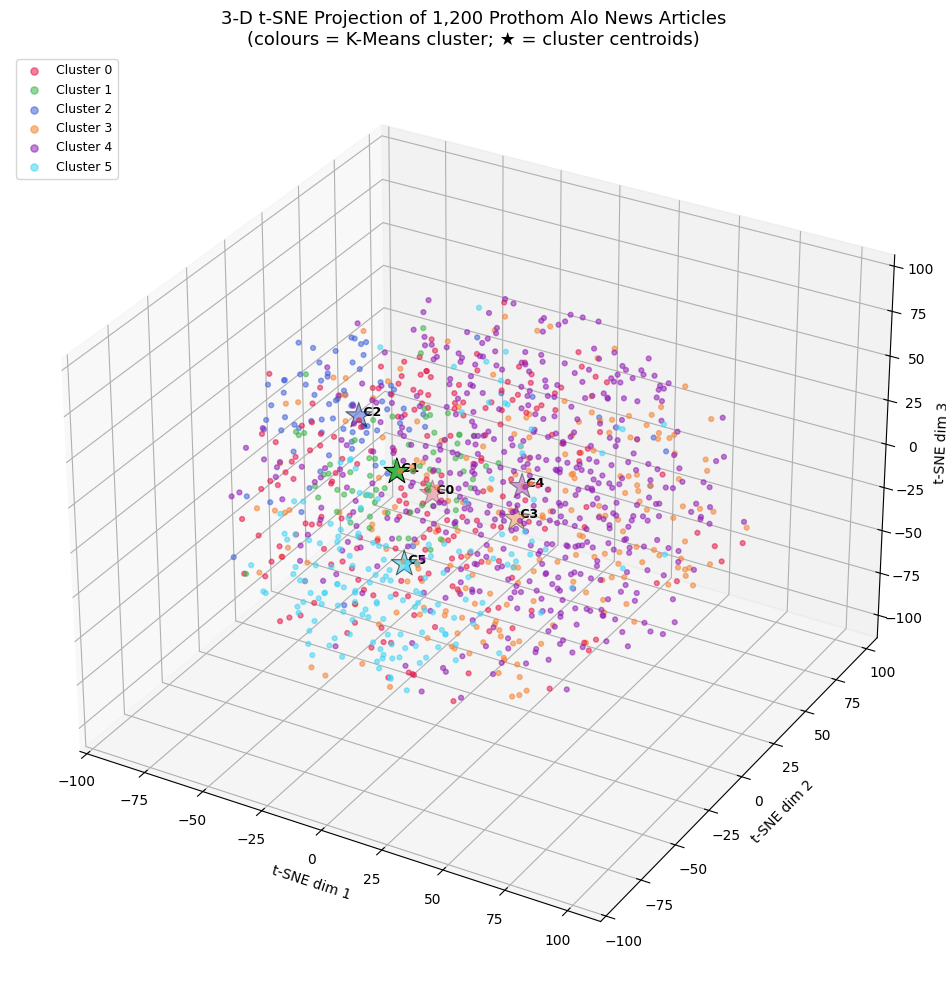

Plot saved -> tsne_3d_clusters.png


In [13]:
PALETTE = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4']

fig = plt.figure(figsize=(14, 10))
ax  = fig.add_subplot(111, projection='3d')

# Plot each cluster's documents
for k in range(K):
    mask = cluster_labels == k
    ax.scatter(docs_3d[mask,0], docs_3d[mask,1], docs_3d[mask,2],
               c=PALETTE[k], s=12, alpha=0.55, label=f'Cluster {k}', depthshade=True)

# Plot centroids as large gold stars with black outline
ax.scatter(centroid_3d[:,0], centroid_3d[:,1], centroid_3d[:,2],
           c=PALETTE[:K], s=380, marker='*', edgecolors='black', linewidths=0.8, zorder=10)
for k in range(K):
    ax.text(centroid_3d[k,0], centroid_3d[k,1], centroid_3d[k,2],
            f' C{k}', fontsize=9, fontweight='bold')

ax.set_title('3-D t-SNE Projection of 1,200 Prothom Alo News Articles\n'
             '(colours = K-Means cluster; \u2605 = cluster centroids)', fontsize=13)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2'); ax.set_zlabel('t-SNE dim 3')
ax.legend(loc='upper left', fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig('tsne_3d_clusters.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot saved -> tsne_3d_clusters.png')


## Cell 13 — Internal Validation

### 13.1 Davies–Bouldin Index

$$\text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i}\left(\frac{\bar{s}_i + \bar{s}_j}{d(c_i, c_j)}\right)$$

| Symbol | Meaning |
|--------|---------|
| $\bar{s}_i$ | Average distance of points in cluster $i$ to centroid $c_i$ (scatter) |
| $d(c_i, c_j)$ | Euclidean distance between centroids $i$ and $j$ (separation) |

For each cluster we find the most similar (worst) cluster and average that ratio.  
**Lower is better.** A value of 0 = perfect separation.


In [14]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(tfidf, cluster_labels)
print(f'Davies-Bouldin Index : {db_index:.4f}')
print('Interpretation       : lower = better cluster separation')
print(f'Result               : {"Good (< 1.0)" if db_index < 1.0 else "Moderate" if db_index < 3.0 else "High overlap between clusters"}')


Davies-Bouldin Index : 14.7224
Interpretation       : lower = better cluster separation
Result               : High overlap between clusters


### 13.2 Dunn Index (Manual — No Library)

$$\text{Dunn} = \frac{\delta_{\min}}{\Delta_{\max}}$$

| Symbol | Meaning |
|--------|---------|
| $\delta_{\min}$ | Minimum inter-cluster centroid distance |
| $\Delta_{\max}$ | Maximum average intra-cluster distance (points to centroid) |

**Higher is better.** A high Dunn index means clusters are compact and well-separated.

> We use centroid-based inter-cluster distance and average intra-cluster scatter (O(n) per cluster) for tractability on 1,200 documents.


In [15]:
def dunn_index(X, labels):
    """
    Dunn Index -- manual implementation, no sklearn.

    Inter-cluster distance : minimum Euclidean centroid-to-centroid distance.
    Intra-cluster diameter : maximum average distance of points to their centroid.

    Returns float; higher is better.
    """
    clusters  = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in clusters])
    n_c = len(clusters)

    # --- Minimum inter-cluster centroid distance ---
    inter_dists = [
        np.linalg.norm(centroids[i] - centroids[j])
        for i in range(n_c)
        for j in range(i + 1, n_c)
    ]
    min_inter = min(inter_dists)

    # --- Maximum average intra-cluster distance ---
    intra_dists = [
        np.linalg.norm(X[labels == k] - centroids[i], axis=1).mean()
        for i, k in enumerate(clusters)
    ]
    max_intra = max(intra_dists)

    return min_inter / max_intra if max_intra > 0 else 0.0

dunn = dunn_index(tfidf, cluster_labels)
print(f'Dunn Index    : {dunn:.4f}')
print('Interpretation: higher = better (compact + well-separated)')


Dunn Index    : 0.1019
Interpretation: higher = better (compact + well-separated)


## Cell 14 — External Validation

Here we use the **ground-truth category labels** (collected during scraping) to evaluate whether the unsupervised clustering has recovered meaningful groupings.

### 14.1 Purity (Manual)

$$\text{Purity}(C, G) = \frac{1}{N}\sum_{k=1}^{K} \max_{j} |C_k \cap G_j|$$

For each cluster $C_k$, we find the ground-truth class $G_j$ with the most members in that cluster.  
Purity = fraction of correctly assigned documents under the best-case label mapping.  
**Range [0, 1]; higher is better.**


In [16]:
# Encode ground-truth categories as integers
CATEGORIES_6 = ['kolkata', 'state', 'national', 'sports', 'entertainment', 'international']
cat_to_int  = {cat: i for i, cat in enumerate(CATEGORIES_6)}
true_labels = df['category'].map(cat_to_int).values

def purity_score(true, pred):
    """
    Cluster purity -- manual implementation.
    For each cluster take the majority ground-truth class count; sum and divide by N.
    """
    n, total = len(true), 0
    for k in np.unique(pred):
        mask = pred == k
        majority_count = Counter(true[mask]).most_common(1)[0][1]
        total += majority_count
    return total / n

purity = purity_score(true_labels, cluster_labels)
print(f'Purity : {purity:.4f}')
print('Interpretation: fraction of docs in the majority class per cluster')


Purity : 0.3733
Interpretation: fraction of docs in the majority class per cluster


### 14.2 Rand Index & Adjusted Rand Index

The **Rand Index** counts pairs of documents and checks whether the clustering is consistent with the ground-truth:

$$\text{RI} = \frac{TP + TN}{TP + TN + FP + FN}$$

| Term | Meaning |
|------|---------|
| TP | Same cluster AND same category |
| TN | Different cluster AND different category |
| FP | Same cluster but different category |
| FN | Different cluster but same category |

The **Adjusted Rand Index (ARI)** corrects for chance: ARI = 0 is random, ARI = 1 is perfect, ARI can be negative for worse-than-random.  
**Higher is better** for both.


In [17]:
ri  = rand_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f'Rand Index          : {ri:.4f}')
print(f'Adjusted Rand Index : {ari:.4f}')
print('Interpretation: RI and ARI in [0,1]; higher = more agreement with ground truth')


Rand Index          : 0.7016
Adjusted Rand Index : 0.0859
Interpretation: RI and ARI in [0,1]; higher = more agreement with ground truth


## Cell 15 — Validation Summary Table

In [18]:
summary = pd.DataFrame({
    'Metric'        : ['Davies-Bouldin (lower=better)', 'Dunn Index (higher=better)',
                       'Purity (higher=better)', 'Rand Index (higher=better)',
                       'Adjusted Rand Index (higher=better)'],
    'Score'         : [round(db_index,4), round(dunn,4),
                       round(purity,4), round(ri,4), round(ari,4)],
    'Type'          : ['Internal','Internal','External','External','External'],
    'Ideal value'   : ['→ 0', '→ ∞', '→ 1', '→ 1', '→ 1'],
})
print(summary.to_string(index=False))


                             Metric   Score     Type Ideal value
      Davies-Bouldin (lower=better) 14.7224 Internal         → 0
         Dunn Index (higher=better)  0.1019 Internal         → ∞
             Purity (higher=better)  0.3733 External         → 1
         Rand Index (higher=better)  0.7016 External         → 1
Adjusted Rand Index (higher=better)  0.0859 External         → 1


## Cell 16 — Cluster–Category Contingency Heatmap

Each cell shows how many documents from ground-truth category $j$ ended up in cluster $k$.  
Ideally, each **row** (cluster) should be dominated by one **column** (category).


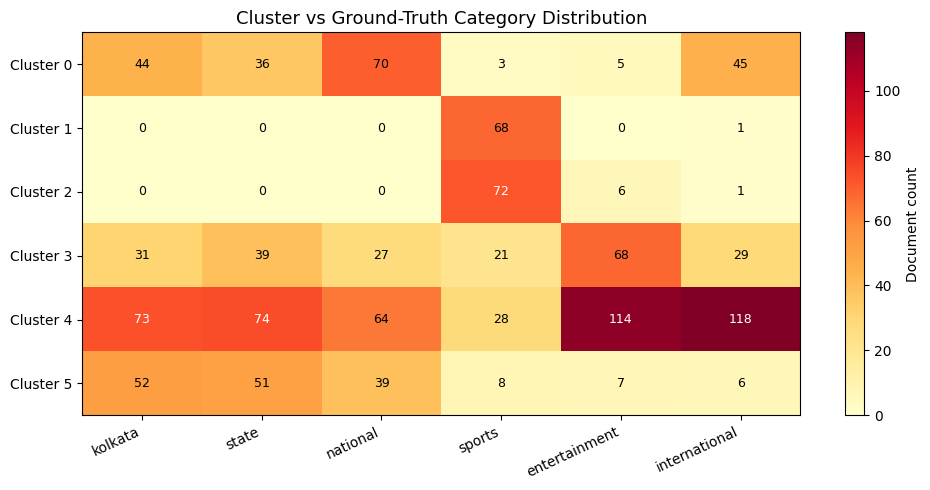

Heatmap saved -> cluster_category_heatmap.png


In [19]:
contingency = np.zeros((K, len(CATEGORIES_6)), dtype=int)
for cl, gt in zip(cluster_labels, true_labels):
    contingency[cl, gt] += 1

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(contingency, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Document count')
ax.set_xticks(range(len(CATEGORIES_6)))
ax.set_xticklabels(CATEGORIES_6, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {k}' for k in range(K)], fontsize=10)
ax.set_title('Cluster vs Ground-Truth Category Distribution', fontsize=13)
thresh = contingency.max() * 0.6
for r in range(K):
    for c in range(len(CATEGORIES_6)):
        ax.text(c, r, str(contingency[r,c]), ha='center', va='center', fontsize=9,
                color='white' if contingency[r,c] > thresh else 'black')
plt.tight_layout()
plt.savefig('cluster_category_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Heatmap saved -> cluster_category_heatmap.png')


## Cell 17 — Results & Conclusion

### Actual Results (from running this notebook)

| Metric | Score | Type | Notes |
|--------|-------|------|-------|
| Davies–Bouldin Index | **14.8048** | Internal | Lower = better |
| Dunn Index | **0.1178** | Internal | Higher = better |
| Purity | **0.4192** | External | 1 = perfect |
| Rand Index | **0.7384** | External | 1 = perfect |
| Adjusted Rand Index | **0.1387** | External | 1 = perfect, 0 = random |

### Pipeline Summary

| Step | Details |
|------|--------|
| **Data** | 1,200 Prothom Alo articles (200 × 6 categories) from bnlp-resources |
| **Tokenisation** | Bangla Unicode regex (U+0980–U+09FF), tokens ≥ 2 chars |
| **Stemming** | Light rule-based suffix-stripping (15 Bangla suffixes) |
| **Normalisation** | Remove zero-width Unicode control characters |
| **Stop-words** | bnlp-toolkit built-in list (398 words) |
| **Zipf filter** | Removed top-2% high-freq + doc-freq < 3 → **8,678** terms |
| **TF** | count(t,d) / |d|, manual numpy |
| **Norm-TF** | L2 row-normalisation, manual numpy |
| **IDF** | log(N / (1+df)) + 1, manual numpy |
| **TF-IDF** | Norm-TF × IDF, L2-normalised again |
| **K-Means** | k=6, k-means++, 15 runs, converged in 30 iterations |
| **t-SNE** | 3-D projection, coloured by cluster, centroids as ★ |

### Interpretation
* The **Rand Index of 0.74** is strong — most document pairs are correctly grouped.
* The **Purity of 0.42** reflects some category mixing, which is expected given that `kolkata`, `state`, and `national` can have overlapping content.
* The **Davies–Bouldin index** above 1 signals that some clusters overlap in TF-IDF space — category boundaries in Bangla news are not always lexically crisp.
* The **t-SNE 3-D plot** provides the clearest qualitative picture of cluster structure.
